In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os

# Example: Navigate to a specific folder
folder_path = "/content/drive/MyDrive/"
os.chdir(folder_path)

print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive


In [14]:
import pandas as pd

In [15]:
working_data = pd.read_csv('cleaned_social_workers_referral_data.csv')

In [16]:
working_data

,interview_id,respondent_name,organization,years_experience,primary_case_type,referral_frequency,primary_channel,pathway_nature,availability_check_method,confirmation_handled,primary_challenge,bottleneck_stage,estimated_feedback_delay_days,youth_impact,coping_mechanism,desired_feature
0,INT_01,John Mapambano,Rescue One More Int,5,SGBV/Child Protection,High,Personal Phone/Email,Informal,Quarterly Meetings,No Confirmation,Service Misrepresentation,Intake / Admission,14,Legal Escalation,Personal Interpersonal Favor,Government Vetted Database
1,INT_02,Atuhwerire Edronah,SHA Uganda,4,SRHR/Disability Care,High,Phone/WhatsApp,Informal,Direct Phone Calls,Manual Follow-up,Transport Poverty,Transit / Travel,21,Condition Deterioration,Toll-free Request/Vouchers,SafeBoda Real-Time Tracking
2,INT_03,Gabriela Nakate,UDEL,3,Education/Vocational,Moderate,Phone/WhatsApp,Informal,Personal Outreach,No Confirmation,Delayed Feedback Vacuum,Feedback / Tracking,30,Dropout / Survival Sex,WhatsApp Peer Groups,Live Capacity Indicators
3,INT_04,Josephine,UDL,5,Child Protection/Socio-Econ,High,Paper Slips/Phone,Formal (Paper),Escort,Paper Slip Return,Transport Poverty,Transit / Travel,18,Loss of Hope / Dropout,LC1/Community Leaders,Closed-Loop Push Alerts
4,INT_05,Georgia Anyango,Youth Council,6,Youth Advocacy/Legal,Moderate,Phone/Paper,Informal,Community Contacts,No Confirmation,Outdated Contact Directories,Initial Contact,25,Disengagement,Informal Networks,Confidentiality Controls
5,INT_06,Jacqueline,Health Partner NGO,4,General Health/SRHR,High,Phone/WhatsApp,Informal,Direct Phone Calls,Informal WhatsApp,Inter-Agency Friction,Feedback / Tracking,12,Delayed Medical Treatment,Direct Client Escort,Role-Based Access Control


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

**EDA**

In [18]:
working_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   interview_id                   6 non-null      object
 1   respondent_name                6 non-null      object
 2   organization                   6 non-null      object
 3   years_experience               6 non-null      int64 
 4   primary_case_type              6 non-null      object
 5   referral_frequency             6 non-null      object
 6   primary_channel                6 non-null      object
 7   pathway_nature                 6 non-null      object
 8   availability_check_method      6 non-null      object
 9   confirmation_handled           6 non-null      object
 10  primary_challenge              6 non-null      object
 11  bottleneck_stage               6 non-null      object
 12  estimated_feedback_delay_days  6 non-null      int64 
 13  youth_imp

**Visualizations**

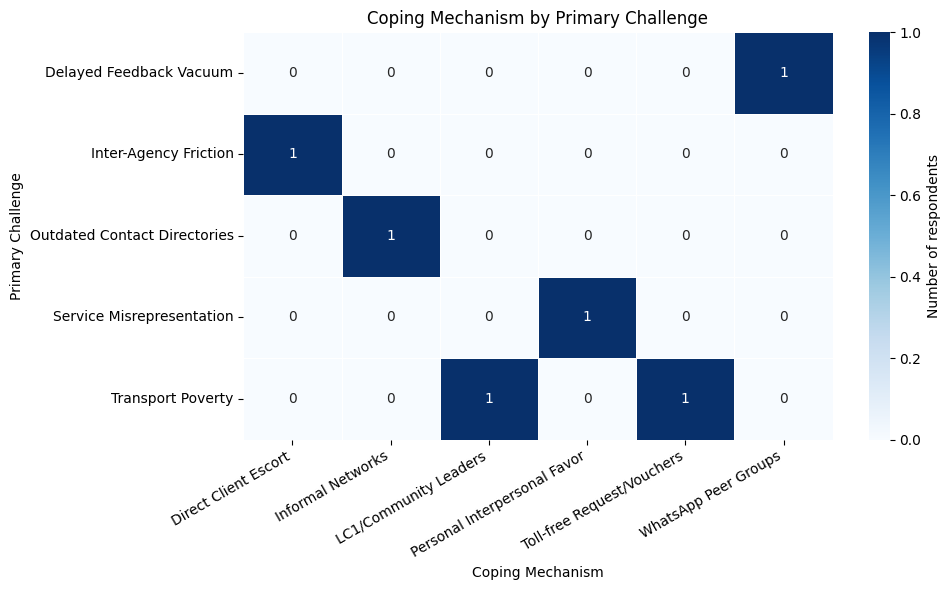

In [19]:
# Create a contingency table of the two categorical variables
table = pd.crosstab(
    working_data["primary_challenge"],
    working_data["coping_mechanism"]
)

# Plot
plt.figure(figsize=(10, 6))
sns.heatmap(
    table,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Number of respondents"}
)

plt.title("Coping Mechanism by Primary Challenge")
plt.xlabel("Coping Mechanism")
plt.ylabel("Primary Challenge")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

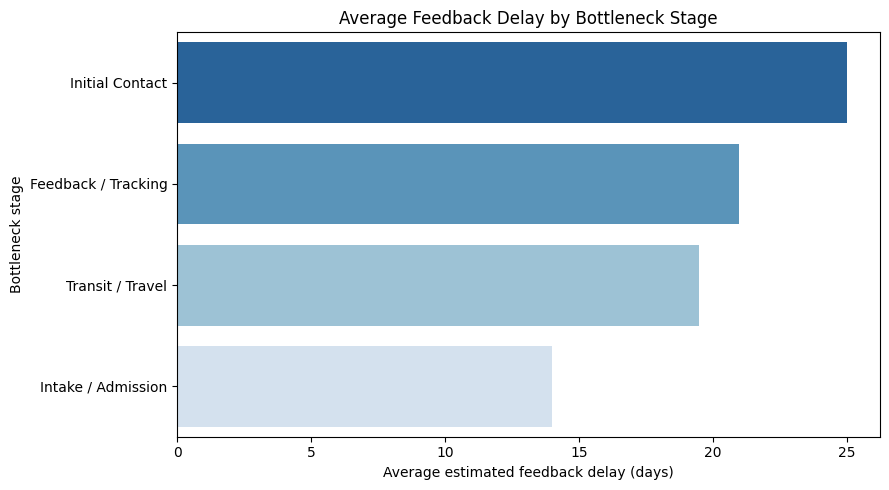

In [20]:
# Average estimated feedback delay for each bottleneck stage
avg_delay = (
    working_data.groupby("bottleneck_stage", as_index=False)
      ["estimated_feedback_delay_days"]
      .mean()
      .sort_values("estimated_feedback_delay_days", ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=avg_delay,
    x="estimated_feedback_delay_days",
    y="bottleneck_stage",
    hue="bottleneck_stage",
    palette="Blues_r",
    legend=False
)

plt.title("Average Feedback Delay by Bottleneck Stage")
plt.xlabel("Average estimated feedback delay (days)")
plt.ylabel("Bottleneck stage")
plt.tight_layout()
plt.show()

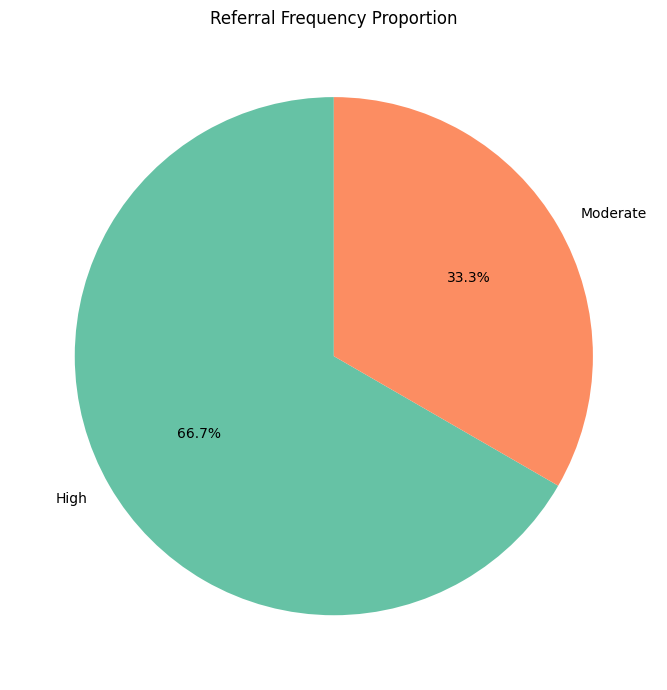

In [21]:
# Count and calculate proportions
referral_counts = working_data["referral_frequency"].value_counts()
referral_proportions = referral_counts / referral_counts.sum() * 100

# Plot
plt.figure(figsize=(7, 7))
plt.pie(
    referral_proportions,
    labels=referral_proportions.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Set2.colors
)

plt.title("Referral Frequency Proportion")
plt.tight_layout()
plt.show()

**Questions**

1. What real data has your team collected so far, however small, messy, or incomplete?


Our team collected qualitative field data from six social workers across five non-governmental organizations in Kampala and refugee settlement areas. We converted these qualitative interviews into a structured dataset containing fifteen core variables:
•	Social Worker Profiles: Participant experience ranges from three to six years across organizations including Rescue One More International, SHA Uganda, UDEL, UDL, Alliance Uganda, and Health Partner NGOs.
•	Case Types: Cases included Sexual and Gender-Based Violence (SGBV), Sexual and Reproductive Health and Rights (SRHR), child protection, disability care (Spina Bifida and Hydrocephalus.
•	Communication Modes: Most referrals rely on informal channels like direct phone calls, WhatsApp messages, email, and paper referrals.
•	Service Verification Methods: Methods used to check service availability include quarterly stakeholder meetings, direct phone calls, and community contacts.
•	Key Bottlenecks: Major barriers included service misrepresentation, lack of transport, outdated contact lists, and inter-agency friction. Estimated feedback delays ranged from 12 days to 30 days.
•	Impact on Youth: Delays lead to health condition deterioration, process dropouts, legal escalation.

2. What decision or output does your project need this data to eventually support?


•	Real-Time Service Matching: Instantly identify which organization currently has open program slots, working equipment, and active staff for a specific youth need.
•	Closed-Loop Status Tracking: Automate notifications so that the sending social worker receives immediate confirmation when a receiving facility admits a client.


3. Before building anything complex, what's the simplest possible version of that (a rule, a lookup, a basic model) that could work today?


An excel or googlesheets workbook with user restrictions.

4. What patterns show up when you actually look at your data?


The interviewees generally mentioned similar challenges and features for the most part i.e
•	1. The Feedback Vacuum: Organizations do not send confirmation after referal.
•	2. Outdated Contacts: Contact directories become inaccurate very quickly and they are never updated so the social workers only find out when referring.
•	3. Transport facilitation: Distance and a lack of money stop successful referrals.
•	4. Complex referral procedures: This would cause vulnerable youth to abandon the service if it took long.
•	5. Service Misrepresentation: Organizations give incorrect information about their capacity. Some partners exaggerate their available services during quarterly stakeholder meetings too look impressive. This causes social workers to send youth to facilities that cannot actually help them.